# Import Libraries

In [21]:
import pandas as pd
import numpy as nb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

# Exploring The Data

In [22]:
df=pd.read_csv('/content/drive/MyDrive/datasets/Students Performance/Student_performance_data _.csv')

In [23]:
df.shape

(2392, 15)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 2392 entries, 0 to 2391

Data columns (total 15 columns):

 #   Column             Non-Null Count  Dtype  

---  ------             --------------  -----  

 0   StudentID          2392 non-null   int64  

 1   Age                2392 non-null   int64  

 2   Gender             2392 non-null   int64  

 3   Ethnicity          2392 non-null   int64  

 4   ParentalEducation  2392 non-null   int64  

 5   StudyTimeWeekly    2392 non-null   float64

 6   Absences           2392 non-null   int64  

 7   Tutoring           2392 non-null   int64  

 8   ParentalSupport    2392 non-null   int64  

 9   Extracurricular    2392 non-null   int64  

 10  Sports             2392 non-null   int64  

 11  Music              2392 non-null   int64  

 12  Volunteering       2392 non-null   int64  

 13  GPA                2392 non-null   float64

 14  GradeClass         2392 non-null   float64

dtypes: float64(3), int64(12)

memory usage: 280.4 KB


In [25]:
#check for duplicate
df.duplicated().sum()

0

In [26]:
#check for null values
df.isnull().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


<Axes: >

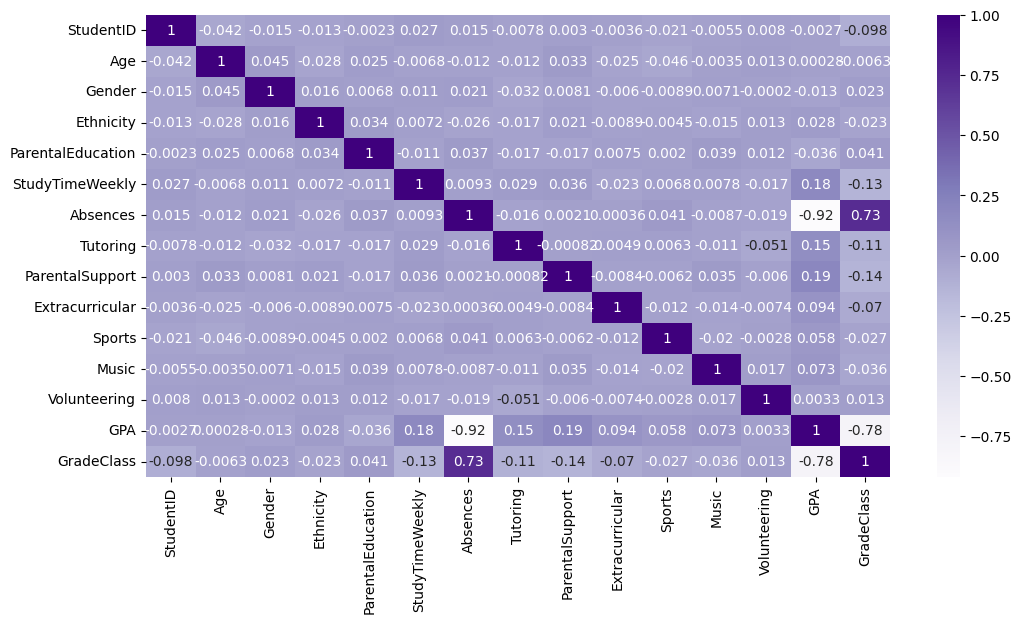

In [27]:
plt.figure(figsize=(12,6))
corr=df.corr()
sns.heatmap(corr,annot=True, cmap="Purples" )

In [28]:
df['Gender']=df['Gender'].replace({0:'Male',1:"Female"})
df['Ethnicity']=df['Ethnicity'].replace({0:'Caucasian',1:"African American",2:"Asian",3:"Other"})
df['ParentalSupport']=df['ParentalSupport'].replace({0: "None" ,1: "Low" ,2: "Moderate" ,3: "High" ,4: "Very High"})
df['Tutoring']=df['Tutoring'].replace({0:'No',1:'Yes'})
df['Extracurricular']=df['Extracurricular'].replace({0:'no',1:'yes'})
df['Sports']=df['Sports'].replace({0:'no',1:'yes'})
df['Music']=df['Music'].replace({0:'no',1:'yes'})
df['Volunteering']=df['Volunteering'].replace({0:'no',1:'yes'})
df['ParentalEducation']=df['ParentalEducation'].replace({0: "None", 1: "High School", 2: "Some College", 3: "Bachelor", 4: "Higher"})
df['GradeClass']=df['GradeClass'].replace({0: "A", 1: "B", 2: "C", 3: "D", 4: "F"})

# Exploratory Data Analysis

In [29]:
data=df['Age'].value_counts().sort_index()
sex=df['Gender'].value_counts().sort_index()

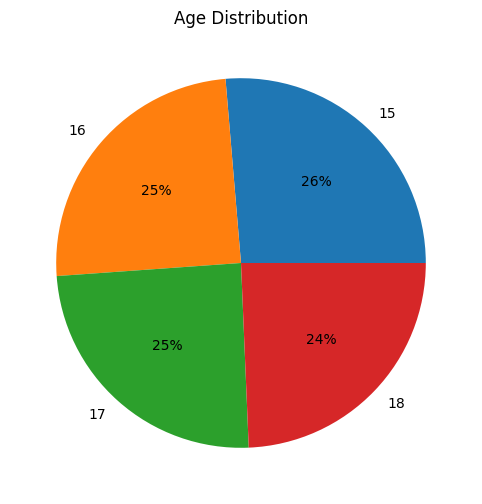

In [30]:
plt.figure(figsize=(12,6))
plt.pie(data,labels=data.index,autopct='%.0f%%')
plt.title('Age Distribution')
plt.show()

the ages are nearly the same

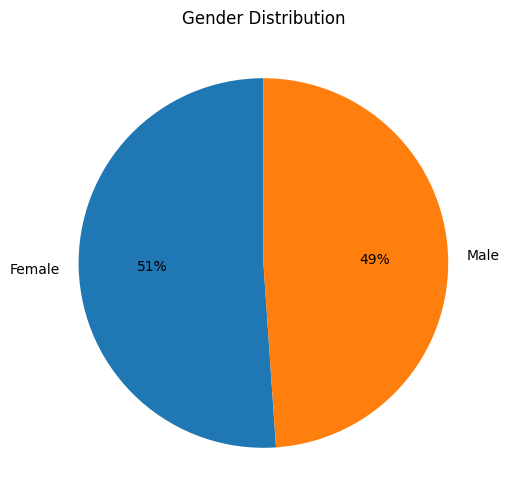

In [31]:
plt.figure(figsize=(12,6))
plt.pie(sex,labels=sex.index,autopct='%.0f%%',startangle=90)
plt.title('Gender Distribution')
plt.show()

the percentage of gender are nearly the same

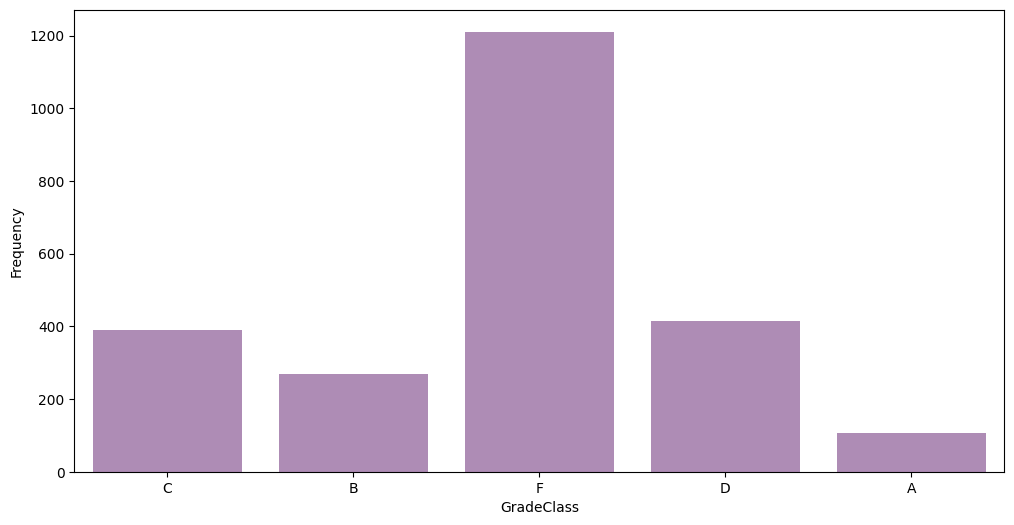

In [32]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='GradeClass',color="#b285bc")
plt.ylabel('Frequency')
plt.show()

the majority of students have GradeClass F

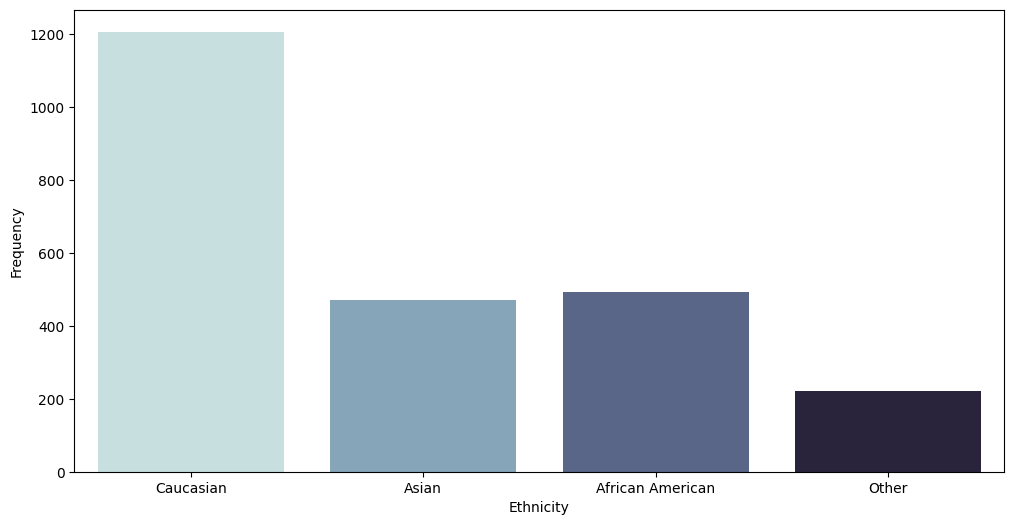

In [33]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,x='Ethnicity',palette='ch:start=.2,rot=-.3')
plt.ylabel('Frequency')
plt.show()

the caucasian race are the most frequent

<Axes: xlabel='GradeClass', ylabel='StudyTimeWeekly'>

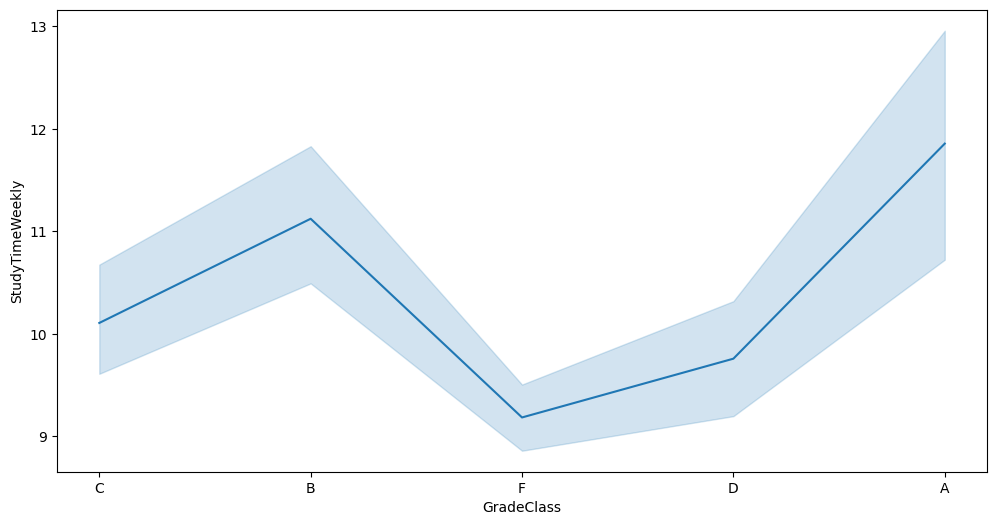

In [34]:
#Ethnicity by gender
plt.figure(figsize=(12,6))
sns.lineplot(data=df,y='StudyTimeWeekly',x='GradeClass')

the students with bad grades study less than 10 hours per week

<Axes: xlabel='GradeClass', ylabel='Absences'>

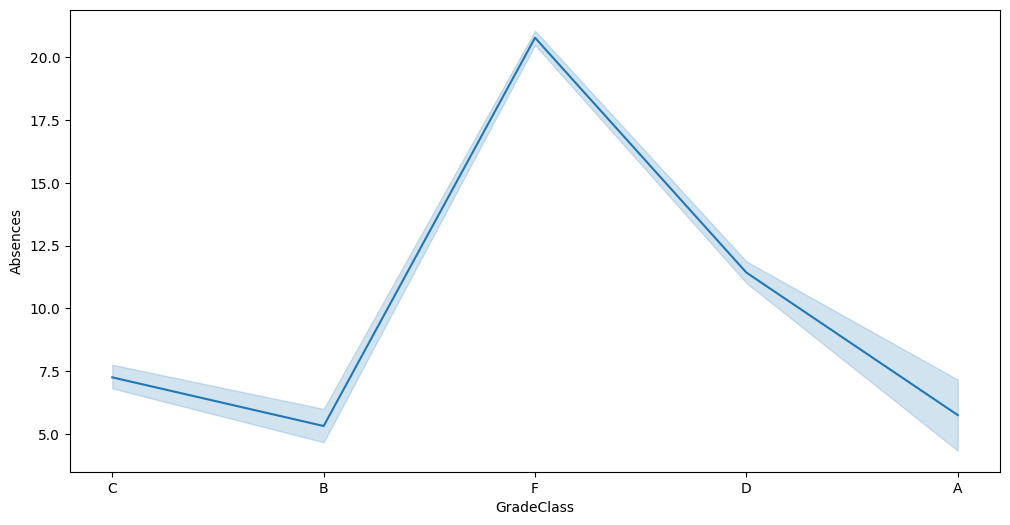

In [35]:
#Ethnicity by gender
plt.figure(figsize=(12,6))
sns.lineplot(data=df,y='Absences',x='GradeClass')

the students with f grade are the one with the most absences

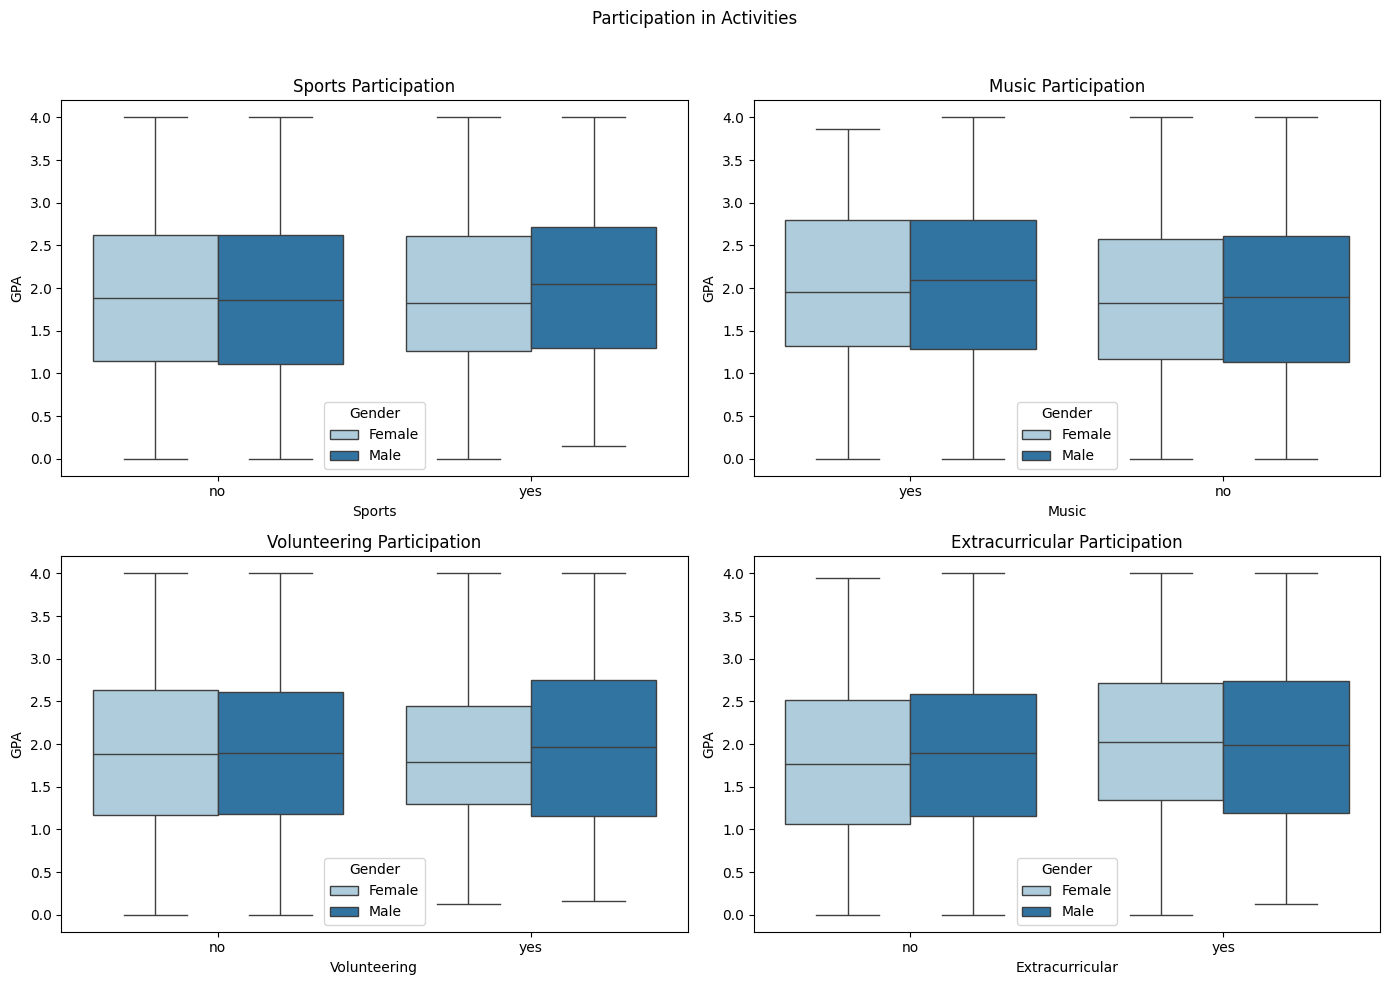

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Participation in Activities')
sns.boxplot(data=df, y='GPA', x='Sports',hue='Gender',palette='Paired' ,ax=axes[0, 0])
axes[0, 0].set_title('Sports Participation')
sns.boxplot(data=df, y='GPA', x='Music',hue='Gender',palette='Paired' , ax=axes[0, 1])
axes[0, 1].set_title('Music Participation')
sns.boxplot(data=df, y='GPA', x='Volunteering',hue='Gender',palette='Paired' , ax=axes[1, 0])
axes[1, 0].set_title('Volunteering Participation')
sns.boxplot(data=df, y='GPA', x='Extracurricular', hue='Gender',palette='Paired' ,ax=axes[1, 1])
axes[1, 1].set_title('Extracurricular Participation')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

the males who participate in sport hava a better GPA , the females who participated in volunteering have worse GPA , both male and females who participated in music have better GPA the same can be said for extracurricular activities

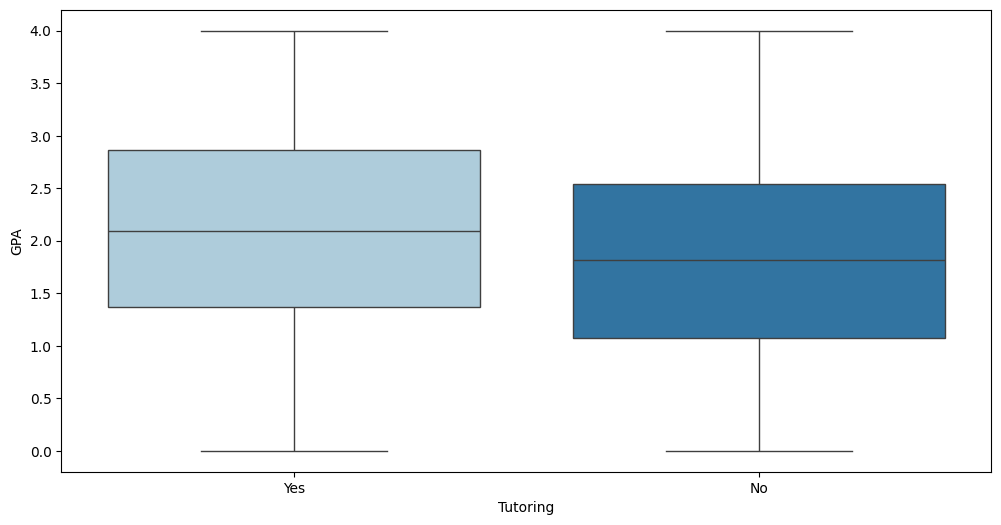

In [37]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df,x='Tutoring',y='GPA',palette='Paired')
plt.show()

those who attended tutoring have a slightly better GPA

# Label Encoding

In [38]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [39]:
df['Gender']=label_encoder.fit_transform(df['Gender'])
df['Ethnicity']=label_encoder.fit_transform(df['Ethnicity'])
df['ParentalSupport']=label_encoder.fit_transform(df['ParentalSupport'])
df['Tutoring']=label_encoder.fit_transform(df['Tutoring'])
df['Extracurricular']=label_encoder.fit_transform(df['Extracurricular'])
df['Sports']=label_encoder.fit_transform(df['Sports'])
df['Music']=label_encoder.fit_transform(df['Music'])
df['Volunteering']=label_encoder.fit_transform(df['Volunteering'])
df['ParentalEducation']=label_encoder.fit_transform(df['ParentalEducation'])
df['GradeClass']=label_encoder.fit_transform(df['GradeClass'])

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 2392 entries, 0 to 2391

Data columns (total 15 columns):

 #   Column             Non-Null Count  Dtype  

---  ------             --------------  -----  

 0   StudentID          2392 non-null   int64  

 1   Age                2392 non-null   int64  

 2   Gender             2392 non-null   int64  

 3   Ethnicity          2392 non-null   int64  

 4   ParentalEducation  2392 non-null   int64  

 5   StudyTimeWeekly    2392 non-null   float64

 6   Absences           2392 non-null   int64  

 7   Tutoring           2392 non-null   int64  

 8   ParentalSupport    2392 non-null   int64  

 9   Extracurricular    2392 non-null   int64  

 10  Sports             2392 non-null   int64  

 11  Music              2392 non-null   int64  

 12  Volunteering       2392 non-null   int64  

 13  GPA                2392 non-null   float64

 14  GradeClass         2392 non-null   int64  

dtypes: float64(2), int64(13)

memory usage: 280.4 KB


# Building The Mode

In [41]:
x=df.drop(['StudentID','GradeClass'],axis=1)
y=df['GradeClass']

In [42]:
scaler = StandardScaler()
scaler.fit(x)
x_scaled = scaler.transform(x)

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,train_size=0.8,random_state=42,stratify=y)

In [44]:
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [45]:
y_pred=model.predict(x_test)

In [46]:
accuracy_score(y_pred,y_test)

0.9144050104384134

<Axes: >

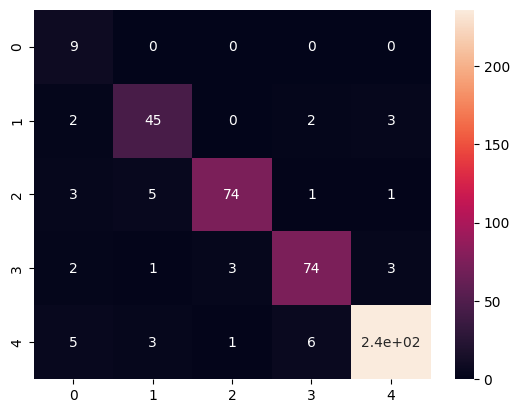

In [47]:
cm=confusion_matrix(y_pred,y_test)
sns.heatmap(cm ,annot=True)

In [48]:
CR=classification_report(y_pred,y_test)
print(CR)

              precision    recall  f1-score   support



           0       0.43      1.00      0.60         9

           1       0.83      0.87      0.85        52

           2       0.95      0.88      0.91        84

           3       0.89      0.89      0.89        83

           4       0.97      0.94      0.96       251



    accuracy                           0.91       479

   macro avg       0.81      0.92      0.84       479

weighted avg       0.93      0.91      0.92       479


